In [1]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
from matplotlib.cm import get_cmap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FuncFormatter
from datetime import timedelta
from matplotlib.patches import Rectangle
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
import tkinter as tk
from tkinter import ttk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import colormaps
from matplotlib.patches import Rectangle
import numpy as np
import xarray as xr
import matplotlib
import matplotlib.cm as cm
import warnings
%matplotlib inline

In [5]:
## reading in cloud information

path = '/home/annierosen16/data/era5sgp/era5_sl_low_med_high_cloud'

cloud_files = sorted(glob.glob(f"{path}/*.nc"))

clouds = xr.open_mfdataset(cloud_files, combine="by_coords")

clouds['valid_time'] = clouds['valid_time'] - pd.Timedelta(hours=6)

clouds = clouds.rename({"valid_time": "time"})

clouds = clouds.where(clouds['time.month'] != 4, drop=True)

In [6]:
## reading in APEs information

with open('/home/annierosen16/master_1979_2025.pkl', 'rb') as f:
    
    master = pickle.load(f)
    
master['date'] = pd.to_datetime(master['date']).dt.date

In [7]:
# with open('/home/annierosen16/mini_master_with_olr.pkl', 'rb') as f:
    
#     mini_master_with_olr = pickle.load(f)

In [8]:
cloud_df = clouds[['hcc', 'lcc', 'mcc']].to_dataframe().reset_index()

cloud_df['date'] = pd.to_datetime(cloud_df['time']).dt.date

cloud_df = cloud_df.drop(columns=['number', 'expver'])

In [9]:
# low cloud cover 

lcc = cloud_df.groupby(['date', 'latitude', 'longitude'])['lcc'].apply(lambda x: x.values).reset_index()

print("lcc complete")

# medium cloud cover 

mcc = cloud_df.groupby(['date', 'latitude', 'longitude'])['mcc'].apply(lambda x: x.values).reset_index()

print("mcc complete")

# high cloud cover 

hcc = cloud_df.groupby(['date', 'latitude', 'longitude'])['hcc'].apply(lambda x: x.values).reset_index()

print("hcc complete")

lcc complete
mcc complete
hcc complete


In [10]:
master_with_cloud = master.merge(lcc, on=['date', 'latitude', 'longitude'], how='left') \
               .merge(mcc, on=['date', 'latitude', 'longitude'], how='left') \
               .merge(hcc, on=['date', 'latitude', 'longitude'], how='left')

In [11]:
dryapes = master_with_cloud[master_with_cloud['dryape']==True].reset_index(drop=True)

wetapes = master_with_cloud[master_with_cloud['wetape']==True].reset_index(drop=True)

no_ape = master_with_cloud[master_with_cloud['APE']==False].reset_index(drop=True)

no_ape = no_ape[no_ape['daily_precip'].apply(lambda x: isinstance(x, (list, np.ndarray)) and len(x) == 24)]

In [12]:
master_with_cloud = master_with_cloud[master_with_cloud['daily_precip'].apply(lambda x: isinstance(x, (list, np.ndarray)) and len(x) == 24)].reset_index(drop=True)

master_with_cloud['daily_precip_sum'] = master_with_cloud['daily_precip'].apply(lambda x: np.sum(x))

no_precip_rows = master_with_cloud[master_with_cloud['daily_precip_sum'] == 0].reset_index(drop=True)

In [13]:
# # lcc 

n_dry_events = dryapes.shape[0]

n_wet_events = wetapes.shape[0]

# dry_lcc_array = np.stack(dryapes['lcc'].values)

# wet_lcc_array = np.stack(wetapes['lcc'].values)

# dry_lcc_composite = dry_lcc_array.mean(axis=0)

# wet_lcc_composite = wet_lcc_array.mean(axis=0)

# no_ape_lcc_array = np.stack(no_ape['lcc'].values)

# no_ape_lcc_composite = no_ape_lcc_array.mean(axis=0)

# no_precip_lcc_array = np.stack(no_precip_rows['lcc'].values)

# no_precip_lcc_composite = no_precip_lcc_array.mean(axis=0)

# # mcc 

# dry_mcc_array = np.stack(dryapes['mcc'].values)

# wet_mcc_array = np.stack(wetapes['mcc'].values)

# dry_mcc_composite = dry_mcc_array.mean(axis=0)

# wet_mcc_composite = wet_mcc_array.mean(axis=0)

# no_ape_mcc_array = np.stack(no_ape['mcc'].values)

# no_ape_mcc_composite = no_ape_mcc_array.mean(axis=0)

# no_precip_mcc_array = np.stack(no_precip_rows['mcc'].values)

# no_precip_mcc_composite = no_precip_mcc_array.mean(axis=0)

# # hcc 

# dry_hcc_array = np.stack(dryapes['hcc'].values)

# wet_hcc_array = np.stack(wetapes['hcc'].values)

# dry_hcc_composite = dry_hcc_array.mean(axis=0)

# wet_hcc_composite = wet_hcc_array.mean(axis=0)

# no_ape_hcc_array = np.stack(no_ape['hcc'].values)

# no_ape_hcc_composite = no_ape_hcc_array.mean(axis=0)

# no_precip_hcc_array = np.stack(no_precip_rows['hcc'].values)

# no_precip_hcc_composite = no_precip_hcc_array.mean(axis=0)

def composite_mean_se(df, col, n, ddof=1):
    """
    Compute composite mean, std, and SE for array-valued column.
    SE = std / sqrt(n), where n is event count.
    """
    arr = np.stack(df[col].values)  # (n_events, ...)
    mean = np.nanmean(arr, axis=0)
    std  = np.nanstd(arr, axis=0, ddof=ddof) if n > 1 else np.full_like(mean, np.nan)
    se   = std / np.sqrt(n) if n > 1 else np.full_like(mean, np.nan)
    return mean, std, se

dry_lcc_composite, dry_lcc_std, dry_lcc_se = composite_mean_se(
    dryapes, "lcc", n_dry_events
)

wet_lcc_composite, wet_lcc_std, wet_lcc_se = composite_mean_se(
    wetapes, "lcc", n_wet_events
)

dry_mcc_composite, dry_mcc_std, dry_mcc_se = composite_mean_se(
    dryapes, "mcc", n_dry_events
)

wet_mcc_composite, wet_mcc_std, wet_mcc_se = composite_mean_se(
    wetapes, "mcc", n_wet_events
)

dry_hcc_composite, dry_hcc_std, dry_hcc_se = composite_mean_se(
    dryapes, "hcc", n_dry_events
)

wet_hcc_composite, wet_hcc_std, wet_hcc_se = composite_mean_se(
    wetapes, "hcc", n_wet_events
)

In [15]:
# Low cloud cover
with open('/home/annierosen16/diurnal_lcc_1979_2025.pkl', 'wb') as f:
    pickle.dump({
        'dry_mean': dry_lcc_composite,
        'dry_std':  dry_lcc_std,
        'dry_se':   dry_lcc_se,
        'wet_mean': wet_lcc_composite,
        'wet_std':  wet_lcc_std,
        'wet_se':   wet_lcc_se,
    }, f)

# Mid-level cloud cover
with open('/home/annierosen16/diurnal_mcc_1979_2025.pkl', 'wb') as f:
    pickle.dump({
        'dry_mean': dry_mcc_composite,
        'dry_std':  dry_mcc_std,
        'dry_se':   dry_mcc_se,
        'wet_mean': wet_mcc_composite,
        'wet_std':  wet_mcc_std,
        'wet_se':   wet_mcc_se,
    }, f)

# High cloud cover
with open('/home/annierosen16/diurnal_hcc_1979_2025.pkl', 'wb') as f:
    pickle.dump({
        'dry_mean': dry_hcc_composite,
        'dry_std':  dry_hcc_std,
        'dry_se':   dry_hcc_se,
        'wet_mean': wet_hcc_composite,
        'wet_std':  wet_hcc_std,
        'wet_se':   wet_hcc_se,
    }, f)

print("All cloud cover files saved.")

All cloud cover files saved.


In [ ]:
# # Time axis
# hours = list(range(24))

# # Colors (muted palette)
# dry_color = '#d95f02'        # Muted orange

# wet_color = '#7570b3'        # Muted purple

# # Create 1x2 subplot layout
# fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

# # --- Dry APE ---

# axs[0].plot(hours, dry_lcc_composite, label='LCC (1000 - 800 hPa)', color=dry_color, lw=2)

# axs[0].plot(hours, dry_mcc_composite, label='MCC (800 - 450 hPa)', color=dry_color, lw=2, linestyle='--')

# axs[0].plot(hours, dry_hcc_composite, label='HCC (< 450 hPa)', color=dry_color, lw=2, linestyle=':')

# axs[0].set_title('Dry APEs Cloud Cover', fontsize=18)

# axs[0].set_ylim(0, 1)

# axs[0].set_xlabel('Hour (LST)', fontsize=16)

# axs[0].set_ylabel('Proportion', fontsize=16)

# axs[0].grid(True, linestyle='--', alpha=0.5)

# axs[0].legend(fontsize=12)

# axs[0].set_facecolor('#f9f9f9')

# # --- Wet APE ---

# axs[1].plot(hours, wet_lcc_composite, label='LCC (1000 - 800 hPa)', color=wet_color, lw=2)

# axs[1].plot(hours, wet_mcc_composite, label='MCC (800 - 450 hPa)', color=wet_color, lw=2, linestyle='--')

# axs[1].plot(hours, wet_hcc_composite, label='HCC (< 450 hPa)', color=wet_color, lw=2, linestyle=':')

# axs[1].set_title('Wet APEs Cloud Cover', fontsize=18)

# axs[1].set_ylim(0, 1)

# axs[1].set_xlabel('Hour (LST)', fontsize=16)

# axs[1].grid(True, linestyle='--', alpha=0.5)

# axs[1].legend(fontsize=12)

# axs[1].set_facecolor('#f9f9f9')

# # Final layout adjustments

# for ax in axs.flat:
    
#     ax.set_xticks(hours[::3])
    
#     ax.tick_params(axis='both', labelsize=16)

# # fig.suptitle('Figure 3', fontsize=16, fontweight='bold')

# plt.tight_layout(rect=[0, 0, 1, 0.95])

# plt.show()

In [14]:
# # Time axis
# hours = list(range(24))

# # Colors (muted palette)
# dry_color = '#d95f02'   # Muted orange
# wet_color = '#7570b3'   # Muted purple

# fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

# # ==========================
# # DRY APE
# # ==========================
# axs[0].plot(hours, dry_lcc_composite, color=dry_color, lw=2)
# axs[0].fill_between(hours,
#                     dry_lcc_composite - dry_lcc_se,
#                     dry_lcc_composite + dry_lcc_se,
#                     color=dry_color, alpha=0.5)

# axs[0].plot(hours, dry_mcc_composite, color=dry_color, lw=2, linestyle='--')
# axs[0].fill_between(hours,
#                     dry_mcc_composite - dry_mcc_se,
#                     dry_mcc_composite + dry_mcc_se,
#                     color=dry_color, alpha=0.5)

# axs[0].plot(hours, dry_hcc_composite, color=dry_color, lw=2, linestyle=':')
# axs[0].fill_between(hours,
#                     dry_hcc_composite - dry_hcc_se,
#                     dry_hcc_composite + dry_hcc_se,
#                     color=dry_color, alpha=0.5)

# axs[0].set_title('Dry APEs Cloud Cover', fontsize=16)
# axs[0].set_ylim(0, 1)
# axs[0].set_xlabel('Hour (LST)', fontsize=14)
# axs[0].set_ylabel('Proportion', fontsize=14)
# axs[0].grid(True, linestyle='--', alpha=0.4)
# axs[0].set_facecolor('#f9f9f9')

# # ==========================
# # WET APE
# # ==========================
# axs[1].plot(hours, wet_lcc_composite, color=wet_color, lw=2)
# axs[1].fill_between(hours,
#                     wet_lcc_composite - wet_lcc_se,
#                     wet_lcc_composite + wet_lcc_se,
#                     color=wet_color, alpha=0.5)

# axs[1].plot(hours, wet_mcc_composite, color=wet_color, lw=2, linestyle='--')
# axs[1].fill_between(hours,
#                     wet_mcc_composite - wet_mcc_se,
#                     wet_mcc_composite + wet_mcc_se,
#                     color=wet_color, alpha=0.5)

# axs[1].plot(hours, wet_hcc_composite, color=wet_color, lw=2, linestyle=':')
# axs[1].fill_between(hours,
#                     wet_hcc_composite - wet_hcc_se,
#                     wet_hcc_composite + wet_hcc_se,
#                     color=wet_color, alpha=0.5)

# axs[1].set_title('Wet APEs Cloud Cover', fontsize=16)
# axs[1].set_ylim(0, 1)
# axs[1].set_xlabel('Hour (LST)', fontsize=14)
# axs[1].grid(True, linestyle='--', alpha=0.4)
# axs[1].set_facecolor('#f9f9f9')

# # --------------------------
# # Formatting
# # --------------------------
# for ax in axs.flat:
#     ax.set_xticks(hours[::3])
#     ax.tick_params(axis='both', labelsize=13)

# # Custom legend (cleaner, avoids duplicates)
# from matplotlib.lines import Line2D
# legend_elements = [
#     Line2D([0], [0], color='black', lw=2, label='LCC (1000–800 hPa)'),
#     Line2D([0], [0], color='black', lw=2, linestyle='--', label='MCC (800–450 hPa)'),
#     Line2D([0], [0], color='black', lw=2, linestyle=':', label='HCC (< 450 hPa)')
# ]
# axs[0].legend(handles=legend_elements, fontsize=11, frameon=False)

# # Panel labels
# panel_labels = ["(a)", "(b)"]

# for ax, label in zip(axs, panel_labels):
#     ax.text(
#         0.02, 0.95,
#         label,
#         transform=ax.transAxes,
#         ha="left",
#         va="top",
#         fontsize=14,
#         fontweight="bold"
#     )

# # --------------------------
# # Caption (bold Figure number)
# # --------------------------
# caption = (
#     r"$\bf{Figure\ 3.}$ "
#     "Diurnal cycle of low (LCC), mid-level (MCC), and high (HCC) cloud cover "
#     "for dry (left) and wet (right) APE composites. Shading indicates ±1 "
#     "standard error of the mean computed as "
#     r"$SE=\sigma/\sqrt{n}$, where $\sigma$ is the sample standard deviation "
#     "across events and $n$ is the total number of events."
# )

# # Center caption relative to axes block
# bbox = axs[0].get_position()

# x_center = bbox.x0 + bbox.width

# fig.text(
#     0.5,
#     0.02,
#     caption,
#     ha="center",
#     va="bottom",
#     fontsize=12,
#     wrap=True
# )

# plt.tight_layout(rect=[0.03, 0.10, 1, 1])

# plt.show()

In [2]:
with open('/home/annierosen16/diurnal_lcc_1979_2025.pkl', 'rb') as f:
    lcc = pickle.load(f)

with open('/home/annierosen16/diurnal_mcc_1979_2025.pkl', 'rb') as f:
    mcc = pickle.load(f)

with open('/home/annierosen16/diurnal_hcc_1979_2025.pkl', 'rb') as f:
    hcc = pickle.load(f)

# Unpack LCC
dry_lcc_composite = lcc['dry_mean']
dry_lcc_std       = lcc['dry_std']
dry_lcc_se        = lcc['dry_se']
wet_lcc_composite = lcc['wet_mean']
wet_lcc_std       = lcc['wet_std']
wet_lcc_se        = lcc['wet_se']

# Unpack MCC
dry_mcc_composite = mcc['dry_mean']
dry_mcc_std       = mcc['dry_std']
dry_mcc_se        = mcc['dry_se']
wet_mcc_composite = mcc['wet_mean']
wet_mcc_std       = mcc['wet_std']
wet_mcc_se        = mcc['wet_se']

# Unpack HCC
dry_hcc_composite = hcc['dry_mean']
dry_hcc_std       = hcc['dry_std']
dry_hcc_se        = hcc['dry_se']
wet_hcc_composite = hcc['wet_mean']
wet_hcc_std       = hcc['wet_std']
wet_hcc_se        = hcc['wet_se']

print("All cloud cover files loaded.")

All cloud cover files loaded.


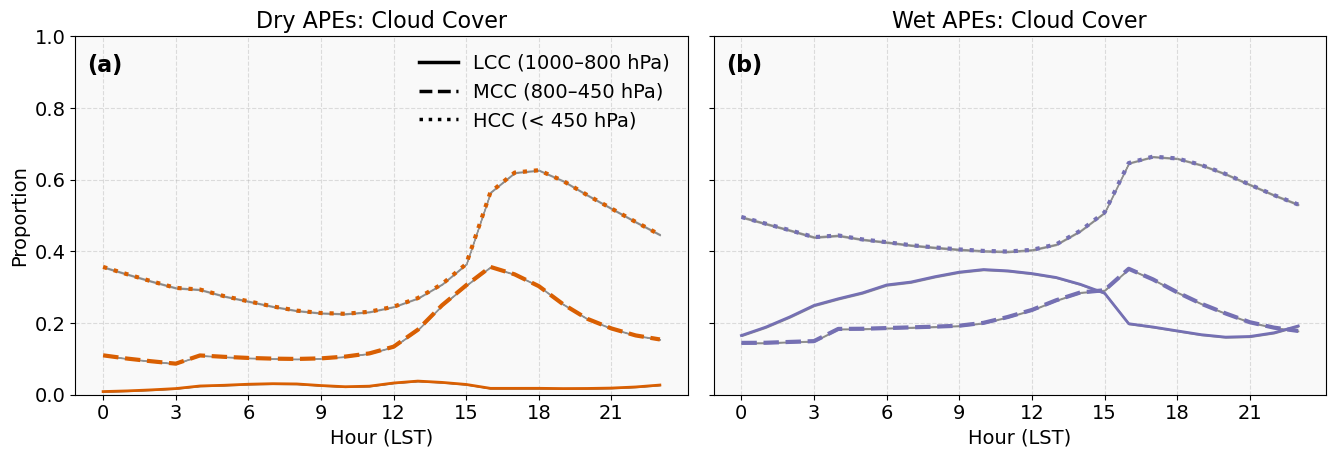

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Time axis
hours = list(range(24))

# Colors (muted palette)
dry_color = '#d95f02'
wet_color = '#7570b3'

# Match font scaling from BLH/CBH figure
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

alpha = 0.8

ci_constant = 1.96

hcc_lw = 3

mcc_lw = 3

lcc_lw = 2

# ==========================
# DRY APE
# ==========================
axs[0].plot(hours, dry_lcc_composite, color=dry_color, lw=lcc_lw)
axs[0].fill_between(hours,
                    dry_lcc_composite - (ci_constant*dry_lcc_se),
                    dry_lcc_composite + (ci_constant*dry_lcc_se),
                    color='grey', alpha=alpha)

axs[0].plot(hours, dry_mcc_composite, color=dry_color, lw=mcc_lw, linestyle='--')
axs[0].fill_between(hours,
                    dry_mcc_composite - (ci_constant*dry_mcc_se),
                    dry_mcc_composite + (ci_constant*dry_mcc_se),
                    color='grey', alpha=alpha)

axs[0].plot(hours, dry_hcc_composite, color=dry_color, lw=hcc_lw, linestyle=':')
axs[0].fill_between(hours,
                    dry_hcc_composite - (ci_constant*dry_hcc_se),
                    dry_hcc_composite + (ci_constant*dry_hcc_se),
                    color='grey', alpha=alpha)

axs[0].set_title('Dry APEs: Cloud Cover', fontsize=16)
axs[0].set_ylim(0, 1)
axs[0].set_xlabel('Hour (LST)')
axs[0].set_ylabel('Proportion')
axs[0].grid(True, linestyle='--', alpha=0.4)
axs[0].set_facecolor('#f9f9f9')

# ==========================
# WET APE
# ==========================
axs[1].plot(hours, wet_lcc_composite, color=wet_color, lw=lcc_lw)
axs[1].fill_between(hours,
                    wet_lcc_composite - (ci_constant*wet_lcc_se),
                    wet_lcc_composite + (ci_constant*wet_lcc_se),
                    color='grey', alpha=alpha)

axs[1].plot(hours, wet_mcc_composite, color=wet_color, lw=mcc_lw, linestyle='--')
axs[1].fill_between(hours,
                    wet_mcc_composite - (ci_constant*wet_mcc_se),
                    wet_mcc_composite + (ci_constant*wet_mcc_se),
                    color='grey', alpha=alpha)

axs[1].plot(hours, wet_hcc_composite, color=wet_color, lw=hcc_lw, linestyle=':')
axs[1].fill_between(hours,
                    wet_hcc_composite - (ci_constant*wet_hcc_se),
                    wet_hcc_composite + (ci_constant*wet_hcc_se),
                    color='grey', alpha=alpha)

axs[1].set_title('Wet APEs: Cloud Cover', fontsize=16)
axs[1].set_ylim(0, 1)
axs[1].set_xlabel('Hour (LST)')
axs[1].grid(True, linestyle='--', alpha=0.4)
axs[1].set_facecolor('#f9f9f9')

# Formatting
for ax in axs.flat:
    ax.set_xticks(hours[::3])
    ax.tick_params(axis='both')

# Custom legend (matches clean style)
legend_elements = [
    Line2D([0], [0], color='black', lw=2.5, label='LCC (1000–800 hPa)'),
    Line2D([0], [0], color='black', lw=2.5, linestyle='--', label='MCC (800–450 hPa)'),
    Line2D([0], [0], color='black', lw=2.5, linestyle=':', label='HCC (< 450 hPa)')
]

axs[0].legend(handles=legend_elements, frameon=False)

# Panel labels (match previous sizing)
panel_labels = ["(a)", "(b)"]
for ax, label in zip(axs, panel_labels):
    ax.text(
        0.02, 0.95,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=16,
        fontweight="bold"
    )

# Caption (mirror BLH/CBH spacing & size)
caption = (
    r"$\bf{Figure\ 3.}$ "
    "Diurnal cycle of low (LCC), mid-level (MCC), and high (HCC) cloud cover "
    "for dry (a) and wet (b) APE composites. Shading indicates 95% confidence intervals computed as "
    r"$\pm 1.96 \times SE$, where $SE = \sigma/\sqrt{n}$, $\sigma$ is the sample standard deviation "
    "across events, and $n$ is the total number of events. "
    "Note: confidence intervals are narrow relative to the composite "
    "and may be difficult to distinguish in some panels."
)

plt.tight_layout(rect=[0.03, 0.20, 1, 1])

# Now get updated axes positions
left  = axs[0].get_position().x0
right = axs[1].get_position().x1
x_center = (left + right) / 2

# fig.text(
#     x_center, 0.045,
#     caption,
#     ha="center",
#     va="bottom",
#     fontsize=15,
#     wrap=True
# )

fig.savefig("/home/annierosen16/cloud_cover.png", dpi=300, bbox_inches="tight")

plt.show()